# AirBnb Price Prediction

## Objective
Build a machine learning model to predict Airbnb listing prices in Tokyo based on listing characteristics.


## Problem Type
Regression problem (predicting a continuous variable: price)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.2f}'.format) 

## Feature Preparation

### Data Cleaning (Loaded from EDA)

In [2]:
df_original = pd.read_csv("../data/listings.csv", encoding='utf-8-sig')
df_clean = df_original.copy()
df_clean = df_clean.dropna(subset=['price'])
df_clean = df_clean.drop(columns=['neighbourhood_group'])
df_clean.fillna({'reviews_per_month': 0}, inplace=True)
df_clean = df_clean.drop(columns=['last_review'])
upper_limit = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= upper_limit]
df_clean = df_clean[df_clean['minimum_nights'] <= 30]

### Features

In [3]:
df = df_clean.copy()
df.shape

y = df['price']

features = [
    'room_type',
    'neighbourhood',
    'availability_365',
    'number_of_reviews',
    'minimum_nights'
]

X = df[features]

In [4]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,availability_365,number_of_reviews,minimum_nights,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_Akiruno Shi,neighbourhood_Akishima Shi,neighbourhood_Arakawa Ku,neighbourhood_Bunkyo Ku,neighbourhood_Chiyoda Ku,neighbourhood_Chofu Shi,neighbourhood_Chuo Ku,neighbourhood_Edogawa Ku,neighbourhood_Fuchu Shi,neighbourhood_Fussa Shi,neighbourhood_Hachioji Shi,neighbourhood_Hamura Shi,neighbourhood_Higashimurayama Shi,neighbourhood_Higashiyamato Shi,neighbourhood_Hino Shi,neighbourhood_Hinohara Mura,neighbourhood_Inagi Shi,neighbourhood_Itabashi Ku,neighbourhood_Katsushika Ku,neighbourhood_Kita Ku,neighbourhood_Kiyose Shi,neighbourhood_Kodaira Shi,neighbourhood_Koganei Shi,neighbourhood_Kokubunji Shi,neighbourhood_Komae Shi,neighbourhood_Koto Ku,neighbourhood_Kunitachi Shi,neighbourhood_Machida Shi,neighbourhood_Meguro Ku,neighbourhood_Minato Ku,neighbourhood_Mitaka Shi,neighbourhood_Musashino Shi,neighbourhood_Nakano Ku,neighbourhood_Nerima Ku,neighbourhood_Nishitokyo Shi,neighbourhood_Okutama Machi,neighbourhood_Ome Shi,neighbourhood_Ota Ku,neighbourhood_Setagaya Ku,neighbourhood_Shibuya Ku,neighbourhood_Shinagawa Ku,neighbourhood_Shinjuku Ku,neighbourhood_Suginami Ku,neighbourhood_Sumida Ku,neighbourhood_Tachikawa Shi,neighbourhood_Taito Ku,neighbourhood_Tama Shi,neighbourhood_Toshima Ku
0,183,190,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,76,272,3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,305,281,5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,80,284,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,253,150,2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((20079, 54), (5020, 54))

Train-test ratio 8/2

In [6]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Log transform because the data is right-skewed. This helps:
- reducing skew
- makes model stable
- improving prediction

## Data Preparation Summary

- Selected features include room type, neighborhood, availability, number of reviews, and minimum nights based on EDA findings.
- Categorical variables are converted into numerical format using one-hot encoding.
- The dataset was split into training and testing sets using 80/20 ratio.
- Applied log transformation into target variable (price) to reduce skewness and improve model performance.

## First Model (Linear Regression)

### Train Model

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Make Predictions

In [8]:
y_pred_log = model.predict(X_test)

In [9]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

Because model was log transformed, we revert it back

### Evaluate Model

In [10]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = root_mean_squared_error(y_test_actual, y_pred)

mae, rmse

(8808.625052699785, 14789.759411488772)

### Model Evaluation (Linear Regression)

The linear regression was trained to predict Airbnb listing prices.

The model achieved:
- Mean Absolute Error (MAE) : 8808.63
- Root Mean Squared Error : 14789.76

These results indicate that, on average, the model's predictions deviate from actual prices by approximately ¥8808 on average. The higher RMSE suggests the presence of larger prediction errors for some listings, indicating that the model may struggle to capture complex pricing patterns.

## Improving Model

### Scaling Numerical Features

In [11]:
num_cols = ['availability_365', 'number_of_reviews', 'minimum_nights']

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Removing Weak Features

In [13]:
features_reduced = [
    'room_type',
    'neighbourhood',
    'minimum_nights'
]
X_reduced = df[features_reduced]
X_reduced = pd.get_dummies(X_reduced, drop_first=True)

X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### Retrain model

In [14]:
model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred_log = model_reduced.predict(X_test_reduced)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [16]:
mae_reduced = mean_absolute_error(y_test_actual, y_pred)
rmse_reduced = root_mean_squared_error(y_test_actual, y_pred)

mae_reduced, rmse_reduced

(8884.339359280595, 14910.017464240478)

### Modified Model Evaluation (Linear Regression)

- MAE becomes 8885 and RMSE becomes 14910m, the results got worse slightly.
- Even if reviews and availability are weak, they are still useful for model.
- Probable sign of underfitting.

## Random Forest

Why Random Forest?
- Handle non-linear relationship
- Capture interactions automatically
- Work well with many features

### Training Model

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
y_pred_log_rf = rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_log_rf)
y_test_actual = np.expm1(y_test_log)

In [19]:
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test_actual, y_pred_rf)

mae_rf, rmse_rf

(8540.385245814678, 14416.703442103317)

### Model Evaluation (Random Forest)

Random Forest model was trained to predict Airbnb listing prices.

The model achieved:
- Mean Absolute Error (MAE) : 8540.39
- Root Mean Squared Error : 14416.70

Compared to Linear Regression model, performance improved slightly, with MAE improved by approximately ¥300 on average and RMSE by ¥400 on average. This suggest that the Randome Forest model is able to capture some non-linear patterns in data, though improvement is modest, indicating that further feature engineering or model tuning may be needed.


## Feature Importance

In [20]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

availability_365            0.35
number_of_reviews           0.25
minimum_nights              0.09
room_type_Shared room       0.06
room_type_Private room      0.03
neighbourhood_Taito Ku      0.02
neighbourhood_Minato Ku     0.02
neighbourhood_Shinjuku Ku   0.02
neighbourhood_Shibuya Ku    0.02
neighbourhood_Ota Ku        0.01
dtype: float64

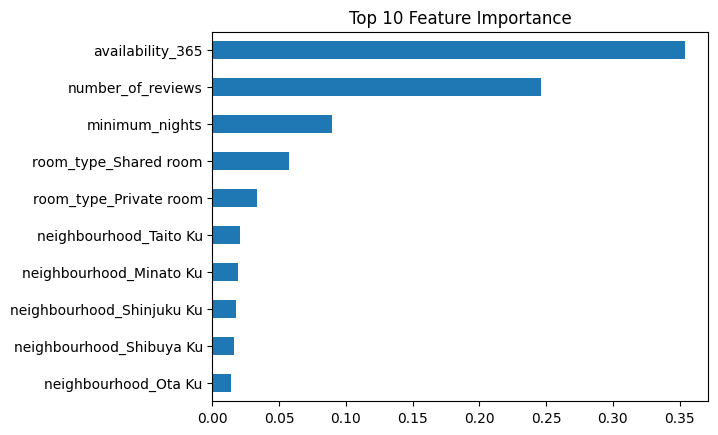

In [21]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [22]:
room_type_importance = feature_importance.filter(like='room_type').sum()
neighbourhood_importance = feature_importance.filter(like='neighbourhood').sum()

room_type_importance, neighbourhood_importance

(np.float64(0.0953700202576819), np.float64(0.2145673728949971))

Because one-hot encoding splits feature, categorical importance are grouped.\
Raw feature importance can be misleading for one-hot enconding variables.

### Feature Importance Insights

- Feature importance results indicate that numerical variables such as availability and number of reviews show high individual feature importance, likely due to their continuous nature and ability to create multiple split points in the model.
- Categorical variables such as room type and neighbourhood are distributed across multiple encoded features; when combined, neighbourhood contributes significantly to price prediction, followed by room type.
- This suggests that location (neighbourhood) plays a major role in determining listing prices, potentially even more than room type in the model.
- These results highlight the importance of carefully interpreting feature importance when using one-hot encoding, as individual feature values may underestimate the true influence of categorical variables.

## Final Model Comparison Table
| Model             | MAE  | RMSE  |
| ----------------- | ---- | ----- |
| Linear Regression | 8808 | 14789 |
| Random Forest     | 8540 | 14416 |
